# Readout frequency optimization

In [8]:
from pathlib import Path

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.experiments.cal12_readout_frequency_optimization import ReadoutFrequencyOptimization

## Run parameters

In [9]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config  # If None, leave the existing hardware flux unchanged
OUTPUT_DIR = Path("data")

QUBITS = ["q1"]
FREQUENCY_SPAN = 0.5e6
FREQUENCY_POINTS = 101
REPETITIONS = 300
RESET_TYPE = "thermal"  # "thermal" or "active" (ConditionalReset)
MULTIPLEXED = True  # True: drive/read out all qubits together (with crosstalk).
                     # False: each qubit's full protocol runs in isolation.

READOUT_AMPLITUDE = None
DRIVE_OUTPUT_ATTENUATION = None
READOUT_OUTPUT_ATTENUATION = None
READOUT_INPUT_ATTENUATION = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_FITTED_DEVICE = SESSION.device_config  # Use None to skip persistence

## Hardware and experiment

In [10]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = ReadoutFrequencyOptimization(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

atexit.register(Instrument.close_all)

<bound method Instrument.close_all of <class 'qcodes.instrument.instrument.Instrument'>>

## Measurement

In [11]:
dataset = experiment.run_measurement(
    frequency_span=FREQUENCY_SPAN,
    frequency_points=FREQUENCY_POINTS,
    repetitions=REPETITIONS,
    reset_type=RESET_TYPE,
    multiplexed=MULTIPLEXED,
    readout_amplitude=READOUT_AMPLITUDE,
    drive_output_attenuation=DRIVE_OUTPUT_ATTENUATION,
    readout_output_attenuation=READOUT_OUTPUT_ATTENUATION,
    readout_input_attenuation=READOUT_INPUT_ATTENUATION,
    timeout=TIMEOUT,
)
dataset

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


<xarray.Dataset> Size: 8kB
Dimensions:           (acq_index_S21_q1: 202)
Coordinates:
    frequency_q1      (acq_index_S21_q1) float64 2kB 5.012e+09 ... 5.012e+09
    state_q1          (acq_index_S21_q1) int64 2kB 0 1 0 1 0 1 0 ... 0 1 0 1 0 1
  * acq_index_S21_q1  (acq_index_S21_q1) int64 2kB 0 1 2 3 4 ... 198 199 200 201
Data variables:
    S21_q1            (acq_index_S21_q1) complex128 3kB (0.001020663404685479...
Attributes:
    tuid:     20260825-050024-726-716be1

## Optional: Simulated data

In [12]:
# dataset = experiment.simulated_data(
#     frequency_span=FREQUENCY_SPAN,
#     frequency_points=FREQUENCY_POINTS,
#     repetitions=5,
#     dispersive_shift=2e6,
#     resonator_linewidth=1.5e6,
#     noise=0.01,
#     seed=42,
# )

## Analysis

In [13]:
results = experiment.analysis()
for qubit, result in results.items():
    print(f"{qubit}: optimal f_ro = {result.best_frequency / 1e9:.9f} GHz "
          f"(detuning {result.detuning / 1e3:+.1f} kHz), "
          f"chi = {result.dispersive_shift / 1e6:.3f} MHz")

q1: optimal f_ro = 5.011695058 GHz (detuning -80.0 kHz), chi = -0.015 MHz


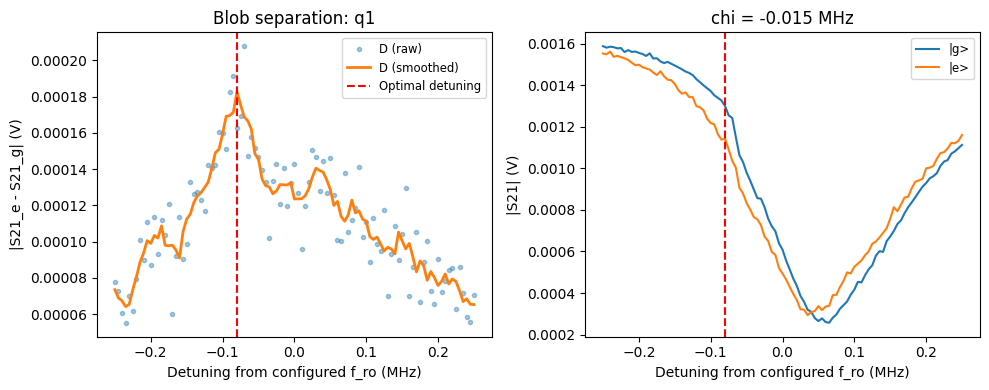

In [14]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

In [8]:
if SAVE_FITTED_DEVICE is not None:
    experiment.update_device()
    saved_path = save_device_configuration(
        hardware_agent.quantum_device,
        SAVE_FITTED_DEVICE,
    )
    print(f"Updated device configuration saved to {saved_path}")

Updated device configuration saved to /home/reny871224/qblox-measurement-nodes/config/dut_config_AS_QRC.json


## Release hardware connection

In [ ]:
from qcodes.instrument import Instrument

Instrument.close_all()